# Forest Models
## Table of Contents
1. Forest Model Selection
2. Feature Engineering
3. Model Selection
  * Regression Models
    * Hyperparameter Tuning
    * Fit Meta-Learners for CATE
  * Causal Forest
4. Comparison of Forest Models
  * Average Treatment Effect (ATE)
  * Conditional Average Treatment Effect (CATE)
5. Comparative Analysis
  * Average Treatment Effect (ATE)
  * Conditional Average Treatment Effect (CATE)
    * Aggregate
    * By Pre-Treatment Income
    * By Race
    * By Years of Education
    * By Age
6. Conclusion


In [1]:
import pandas as pd
import numpy as np
import patsy
import math
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.metrics import mean_squared_error
import statsmodels.api as sm
import sklearn.linear_model as lm
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import RandomForestClassifier
import statsmodels.formula.api as smf
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression


!pip install causaldata
import causaldata

!pip install econml
from econml.metalearners import SLearner
from econml.metalearners import TLearner
from econml.metalearners import XLearner
from econml.dml import CausalForestDML
from econml.score import RScorer

from scipy.stats import norm

import warnings
warnings.simplefilter('ignore')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 21.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for causaldata: filename=causaldata-0.1.5-py3-none-any.whl size=2767646 sha256=10992ee51a714e6b7fdbefa1272080a55bf9f5a23dc779e703eb582756adda39
  Stored in directory: /root/.cache/pip/wheels/fd/42/c7/7665a1c716f3a1518c4f42abcd23054a5701aca1d118c348d7
Successfully built causaldata
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 38.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 45.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.9/155.9 kB 9.4 MB/s eta 0:00:00
  Attempting uninstall: shap
    Found existing installation: shap 0.52.0
    Uninstalling shap-0.52.0:
      Successfully uninstalled shap-0.52.0


## Feature Engineering


In [2]:
# Load the dataset
df_raw = causaldata.nsw_mixtape.load_pandas().data

# Remove specified columns from df
df=df_raw.copy()
df = df.drop(columns=['marr', 'hisp', 'nodegree', 're74'], errors='ignore')

# Handle zeros in re78 before taking log (do +1)
ly78 = np.log(df['re78'] + 1)
ly75 = np.log(df['re75'] + 1)

df['lre78'] = ly78
df['lre75'] = ly75

# Model with all features
X = df[['treat', 'age', 'educ', 'black', 'lre75']]

## Model Selection

Besides the regular regression model from the previous notebook, I will also fit a forest model. In the context of machine learning, they are more appropriate for analyzing especially large and high-dimensional datasets. Both characteristics, however, are not given for my specific dataset, but I will fit these nevertheless, to compare their performance to the baseline regression model.

In this notebook, I will follow a different strategy than before to find the best performing forest model. First, I will set up and compare a tuned regression forest with a tuned causal forest. All forests are honest, which means that they are trained on a different subset of the sample than is being used for estimating the effects. This ensures valid statistical inference.

Then, I will calculate the ATE for both of them using AIPW and calculate the CATE from the regression forest under the S-Learner, T-Learner and X-Learner. Finally, I will compare the CATEs of all models using R-loss, and visually inspect the heterogeneity in estimated treatment effects.

# Regression Forests

In contrast to the regression models I've fitted before, forest models work differently. First of all, regression forests were built for predicting outcomes, but not for estimating treatment effects, which is why I have to calculate Meta-Learners for the CATE later on.

A regression forest, or "random forest regressor", is based on multiple regression trees that were grown individually. Each tree grows by repeatedly splitting the dataset into multiple branches, choosing splits that minimize the MSE between the predicted and actual outcomes within each leaf.

Each leaf's prediction is simply the mean outcome of the training observations that fall into it, and the final regression forest then predicts the average of the outcomes predicted by all the individual trees.

A new data point from the test data is then assigned the same pre-calculated value of the leaf it falls into.


## Hyperparameter Tuning

To ensure that the forest model is fitted correctly to the data and is not overfitting, I will apply a hyperparameter tuning mechanism to learn about the optimal depth of trees and number of sample splits. For this, I will use the GridSearchCV with cross-validation, which systematically tests a range of values and evaluatees their performance over multiple folds.

In [3]:
y_ate_full = df['lre78'].values
X_ate_full = patsy.dmatrix('age + educ + black + lre75 + treat', data=df, return_type='dataframe').values

# Define the parameter grid to search for max_depth
param_grid = {
    'rf__max_depth': [2, 3, 4],
    'rf__min_samples_split': [5, 10, 15]
}

# Initialize the Random Forest model within a pipeline
rf_pipeline = Pipeline([
    ('scale', StandardScaler()),
    ('rf', RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=1))
])

# Set up GridSearchCV with K-fold cross-validation
grid_search_max_depth = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid,
    cv=KFold(n_splits=5, shuffle=True, random_state=42),
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

# Fit GridSearchCV to the full dataset
grid_search_max_depth.fit(X_ate_full[:, 1:], y_ate_full)

print(f"Best max_depth parameter: {grid_search_max_depth.best_params_}")

Fitting 5 folds for each of 9 candidates, totalling 45 fits
Best max_depth parameter: {'rf__max_depth': 2, 'rf__min_samples_split': 15}


In [4]:
# Tuning for the propensity score model of the X-Learner

T = df['treat'].values
X_covariates = df[['age', 'educ', 'black', 'lre75']].values

# Create a pipeline for the propensity score model
model_t_pipeline = Pipeline([
    ('scale', StandardScaler()),
    ('rf_classifier', RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=1))
])

# Define parameter grid
param_grid_t = {
    'rf_classifier__max_depth': [None, 2, 3, 4],
    'rf_classifier__min_samples_split': [10, 20, 30]
}

# Set up GridSearchCV
grid_search_model_t = GridSearchCV(
    estimator=model_t_pipeline,
    param_grid=param_grid_t,
    cv=KFold(n_splits=5, shuffle=True, random_state=42),
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

# Fit GridSearchCV
grid_search_model_t.fit(X_covariates, T)

print(f"\nBest parameters for propensity score model: {grid_search_model_t.best_params_}")

Fitting 5 folds for each of 12 candidates, totalling 60 fits

Best parameters for propensity score model: {'rf_classifier__max_depth': 4, 'rf_classifier__min_samples_split': 10}


## Fit Meta-Learners for CATE

Now, to be able to distinguish between the regression and causal forests (to be introduced later) and between the different meta-learners, I will calculate the CATE under all of them. These CATEs will then later be important to calculate the R-loss, the relevant metric to find the best performing forest model and meta-learner.

I will implement the S-Learner first, which builds a single model and predicts the treatment effect for the treated and untreated participants based that. The CATE is then calculated as the difference between the two predictions for each observation,

$$
\widehat{\tau}(x) = \widehat{\mu}((x,1))-\widehat{\mu}((x,0))
$$

In [5]:
# tuned S-Learner

# Define outcome
Y = df['lre78'].values

# Define the base learner
s_learner_opt_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    max_depth=2,
    min_samples_split=15,
    n_jobs=1
)

# Initialize KFold for cross-validation
n_splits = 5
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

# Array to store out-of-fold CATE predictions
cate_s_learner_opt_oof = np.zeros(len(df))

for fold, (train_index, test_index) in enumerate(kf.split(X_covariates)):

    # Split data for the current fold
    Y_train, Y_test = Y[train_index], Y[test_index]
    T_train, T_test = T[train_index], T[test_index]
    X_covariates_train, X_covariates_test = X_covariates[train_index], X_covariates[test_index]

    # Initialize S-Learner
    sl_opt_fold = SLearner(overall_model=RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        max_depth=2,
        min_samples_split=15,
        n_jobs=1
    ))

    # Fit S-Learner on the training data
    sl_opt_fold.fit(Y_train, T_train, X=X_covariates_train)

    # Predict CATE on test data
    cate_s_learner_opt_oof[test_index] = sl_opt_fold.effect(X=X_covariates_test)

cate_s_learner_pc_opt = (np.exp(cate_s_learner_opt_oof) - 1) * 100

As the S-Learner might not take structural differences between the treated and untreated groups into account, I will additionally estimate the CATE under the T-Learner. This meta-learner fits separate models to the treated and control group and predicts treatment effects for each group based on their own model,

$$
\widehat{\tau}(x)=\widehat{\mu}_{(1)}(x)-\widehat{\mu}_{(0)}(x).
$$



In [6]:
# tuned T-Learner

# Store out-of-fold CATE predictions
cate_t_learner_opt_oof = np.zeros(len(df))

for fold, (train_index, test_index) in enumerate(kf.split(X_covariates)):

    # Split data for the current fold
    Y_train, Y_test = Y[train_index], Y[test_index]
    T_train, T_test = T[train_index], T[test_index]
    X_covariates_train, X_covariates_test = X_covariates[train_index], X_covariates[test_index]

    # Define the base learners
    tl_model_y0_fold = RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        max_depth=2,
        min_samples_split=15,
        n_jobs=1
    )
    tl_model_y1_fold = RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        max_depth=2,
        min_samples_split=15,
        n_jobs=1
    )

    # Initialize new T-Learner
    tl_opt_fold = TLearner(
        models=[tl_model_y0_fold, tl_model_y1_fold]
    )

    # Fit the T-Learner on training data
    tl_opt_fold.fit(Y_train, T_train, X=X_covariates_train)

    # Predict CATE on test data
    cate_t_learner_opt_oof[test_index] = tl_opt_fold.effect(X=X_covariates_test)

cate_t_learner_pc_opt = (np.exp(cate_t_learner_opt_oof) - 1) * 100

Finally, I will apply the X-Learner to find out whether my model suffers from regularization bias. This bias is introduced when we are regularizing the model to try to decrease its variance and prevent overfitting. This additional bias, however, invalidates our confidence intervals and good inference is no longer possible.

The X-Learner is robust to regularization bias by construction. This meta-learner first predicts the outcomes of the control group, $\widehat{\mu}_{(0)}(x)$ using only the sample of the untreated. It then calculates the difference between the actual outcomes of the treated population and the predicted outcomes of the untreated population, $\Delta_i(1)=Y_i-\widehat{\mu}_{(0)}(X_i)$ and uses this difference to predict the treatment effect of the treated participants, $\widehat{\tau}_{(1)}(x)$. Then it applies the same logic to predict the treatment effect $\widehat{\tau}_{(0)}(x)$ for the control group. Finally, the X-Learner predicts the propensity score (likelihood of being treated) and calculates the overall treatment effect:

$$
\widehat{\tau}(x)= \widehat{e}(x) \ \widehat{\tau}_{(0)}(x) + (1-\widehat{e}(x)) \ \widehat{\tau}_{(1)}(x)
$$

In [7]:
# tuned X-Learner

# Define the base learners
xl_outcome_model_tuned = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    max_depth=2,
    min_samples_split=15,
    n_jobs=1
)

# Define learner for propensity score model
xl_propensity_model_tuned = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    max_depth=4,
    min_samples_split=10,
    n_jobs=1
)

# Array to store out-of-fold predictions
cate_x_learner_opt_oof = np.zeros(len(df))

for fold, (train_index, test_index) in enumerate(kf.split(X_covariates)):

    # Split data for the current fold
    Y_train, Y_test = Y[train_index], Y[test_index]
    T_train, T_test = T[train_index], T[test_index]
    X_covariates_train, X_covariates_test = X_covariates[train_index], X_covariates[test_index]

    # Initialize new X-Learner for each fold
    xl_opt_fold = XLearner(
        models=xl_outcome_model_tuned,
        cate_models=xl_outcome_model_tuned,
        propensity_model=xl_propensity_model_tuned
    )

    # Fit the X-Learner on training data
    xl_opt_fold.fit(Y_train, T_train, X=X_covariates_train)

    # Predict CATE on test data
    cate_x_learner_opt_oof[test_index] = xl_opt_fold.effect(X=X_covariates_test)

cate_x_learner_pc_opt = (np.exp(cate_x_learner_opt_oof) - 1) * 100

# Causal Forest

All of the previous methods, however, cannot make sure that there are actually treated observations in each leaf.

For this reason, I will additionally apply a causal forest, which is the average of causal trees that, in contrast to regression trees, maximize the heterogeneity in treatment effects across leaves. The algorithm then calculates the treatment effect in each leaf using a held-out estimation sample, which makes sure that the trees are honest and the final estimates hence are unbiased.

I will first tune the hyperparameters of the model via manual grid search and than set up the CATE to prepare the calculation of the R-loss.


In [8]:
# Hyperparameter tuning for CF

X = X_covariates

# Set up base learners
model_y_tuned = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    max_depth=2,
    min_samples_split=15,
    n_jobs=1
)

model_t_tuned = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    max_depth=3,
    min_samples_split=100,
    n_jobs=1
)

# Define the parameter grid
param_grid_cf = {
    'n_estimators': [48, 100, 200],
    'min_samples_leaf': [1, 2, 3, 4, 5, 10, 20]
}

# Manual Grid Search Implementation
best_score = -np.inf
best_params = {}

# Iterate over parameter grid
for n_estimators_val in param_grid_cf['n_estimators']:
    for min_samples_leaf_val in param_grid_cf['min_samples_leaf']:

        # Define the Causal Forest model
        cf_estimator_manual = CausalForestDML(
            model_y=model_y_tuned,
            model_t=model_t_tuned,
            honest=True,
            cv=5,
            random_state=42,
            n_estimators=n_estimators_val,
            min_samples_leaf=min_samples_leaf_val
        )

        fold_scores = []

        # Perform cross-validation
        for train_index, test_index in kf.split(X, Y, T):
            # Split data for the current fold
            X_train, X_test = X[train_index], X[test_index]
            Y_train, Y_test = Y[train_index], Y[test_index]
            T_train, T_test = T[train_index], T[test_index]

            # Fit the model on the training fold
            cf_estimator_manual.fit(Y_train, T_train, X=X_train)

            # Evaluate the model on the test fold (R-squared of CATE))
            score = cf_estimator_manual.score(Y_test, T_test, X=X_test)
            fold_scores.append(score)

        mean_fold_score = np.mean(fold_scores)

        # Check if this is the best score
        if mean_fold_score > best_score:
            best_score = mean_fold_score
            best_params = {
                'n_estimators': n_estimators_val,
                'min_samples_leaf': min_samples_leaf_val
            }

print(f"\nBest parameters for Causal Forest: {best_params}")


Best parameters for Causal Forest: {'n_estimators': 48, 'min_samples_leaf': 5}


In [9]:
# CATE of CF

# Array to store out-of-fold predictions
cate_cf_opt_oof = np.zeros(len(df))

for fold, (train_index, test_index) in enumerate(kf.split(X)):

    # Split data for the current fold
    Y_train, Y_test = Y[train_index], Y[test_index]
    T_train, T_test = T[train_index], T[test_index]
    X_train, X_test = X[train_index], X[test_index]

    # Store the best estimator
    cf_honest_opt_fold = CausalForestDML(
        model_y=model_y_tuned,
        model_t=model_t_tuned,
        honest=True,
        cv=5,
        random_state=42,
        **best_params
    )

    # Fit the model on the training data
    cf_honest_opt_fold.fit(Y_train, T_train, X=X_train)

    # Predict CATE on the test data
    cate_cf_opt_oof[test_index] = cf_honest_opt_fold.effect(X=X_test)

cate_cf_pc_opt = (np.exp(cate_cf_opt_oof) - 1) * 100

# Comparison of Forest Models

Now, to compare the performance of the forest models, I will calculate the R-loss to find out which model adds value beyond a baseline value, and additionally visually inspect the CATEs.

The R-Loss is based on Robinson's transformation, and its minimizer is usually used as a consistent estimator (despite hypothetical confounding bias) for the average treatment effect. It can also be used as a loss function to learn the CATE under the so-called R-Learner, or for model selection, which is the use case here.

To do model selection using the R-Loss, one needs to compute the R-Loss under a specific model and a baseline model. The baseline model is a fixed constant-effect model.
Finally, I am calculating a score based on the R-Loss of the specific model and the R-Loss of the baseline:

$$
R-Score = 1- \frac {\widehat{L}(\widehat{\tau}(\cdot))} {\widehat{L}(\widehat{\tau}_0(\cdot))}
$$

with R-Loss

$$
\widehat{L}(\widehat{\tau}) = \frac{1}{n} \sum_{i=1}^n[(Y_i-\widehat{m}(X_i)-\widehat{\tau}(X_i)(W_i-\widehat{e}(X_i)))^2],
$$

derived from Robinson's transformation. The higher the score, the lower is the specific model's R-Loss and the better is the model performance compared to the constant baseline.




In [10]:
# Calculate R-loss score

# Set up the RScorer with the nuisance models from the R-Learner
r_scorer = RScorer(
    model_y=model_y_tuned,
    model_t=model_t_tuned
)

# Fit the RScorer to the data
r_scorer.fit(Y, T, X=X_covariates)

# Calculate R-loss
r_loss_s_learner_opt = r_scorer.score(sl_opt_fold)
r_loss_t_learner_opt = r_scorer.score(tl_opt_fold)
r_loss_x_learner_opt = r_scorer.score(xl_opt_fold)
r_loss_cf_opt = r_scorer.score(cf_honest_opt_fold)

# Create table
table_forest = pd.DataFrame({
    'S-Learner': [r_loss_s_learner_opt],
    'T-Learner': [r_loss_t_learner_opt],
    'X-Learner': [r_loss_x_learner_opt],
    'Causal Forest': [r_loss_cf_opt]
}).T
table_forest.columns = ['R-Score']
display(table_forest)
table_forest.to_csv('model_evaluation_forest_R-loss.csv')

,R-Score
S-Learner,-0.000184
T-Learner,0.022555
X-Learner,0.021118
Causal Forest,0.032376


The table shows that all models except the S-Learner have lower losses than a constant model and therefore fit the data better.
The Causal Forest has the best R-Score, followed by the T-Learner and X-Learner.

Given that my sample is quite small (N=445), a little bit unbalanced and not high-dimensional, I will choose the X-Learner as the best model.


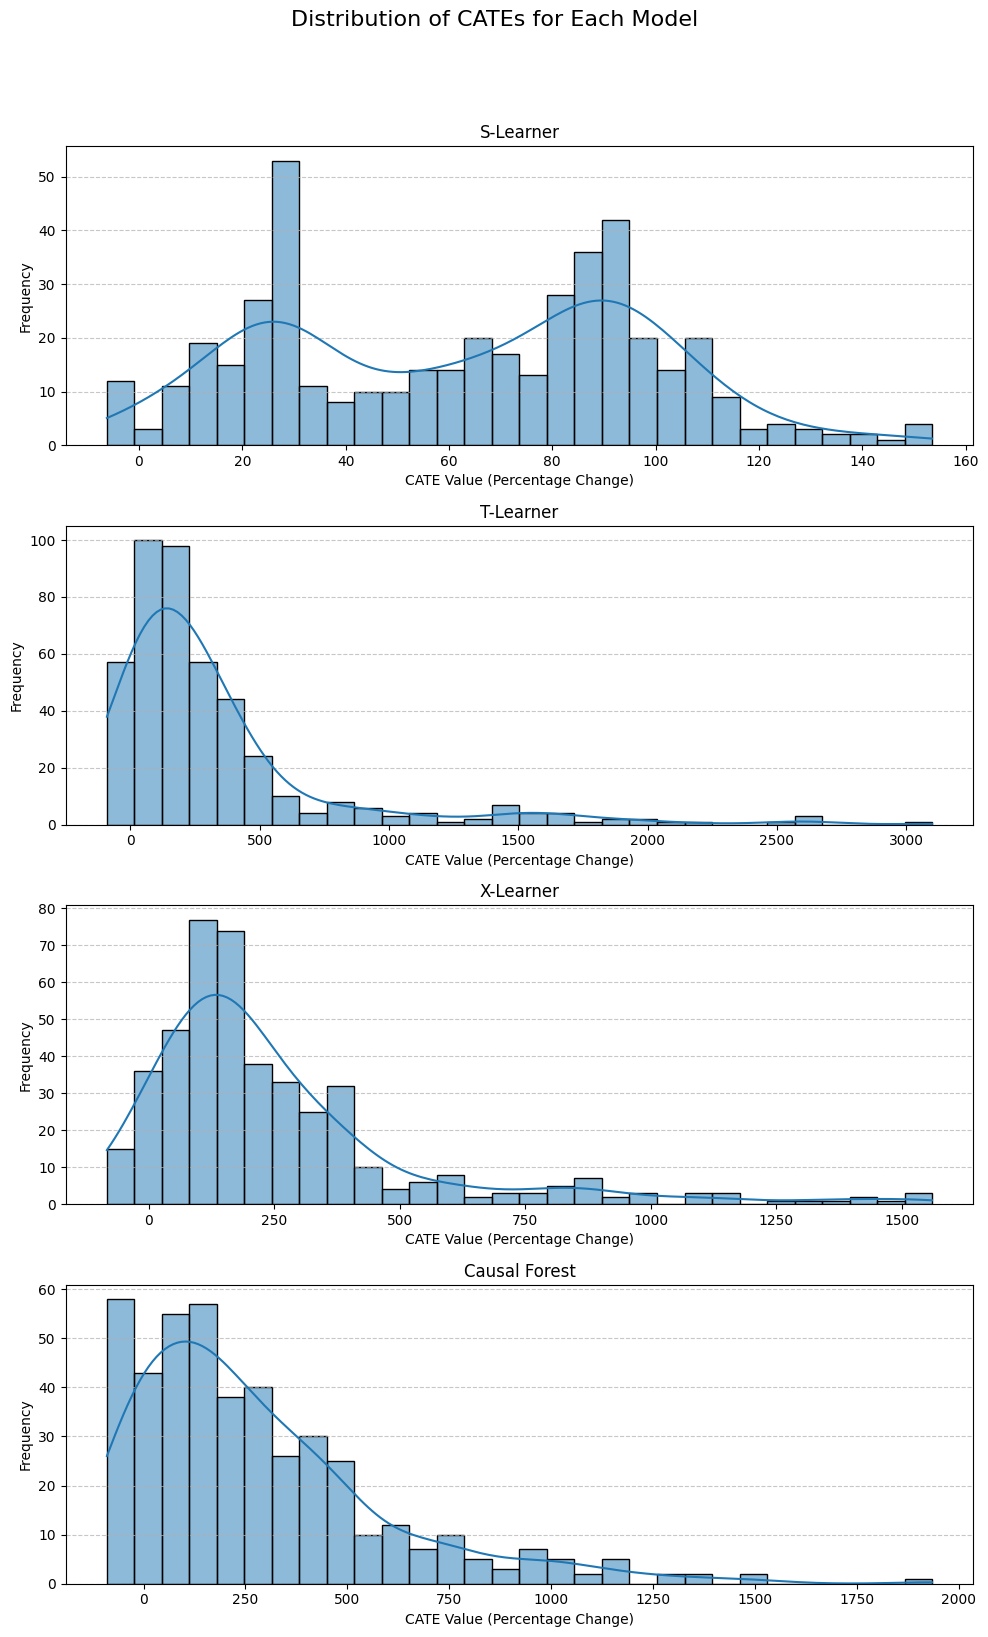

In [11]:
# Plot all CATEs for comparison
cate_models = {
    'S-Learner': cate_s_learner_pc_opt,
    'T-Learner': cate_t_learner_pc_opt,
    'X-Learner': cate_x_learner_pc_opt,
    'Causal Forest': cate_cf_pc_opt
}


fig, axes = plt.subplots(len(cate_models), 1, figsize=(10, 16))
axes = axes.flatten()

for i, (model_name, cate_values) in enumerate(cate_models.items()):
    sns.histplot(cate_values, bins=30, kde=True, ax=axes[i])
    axes[i].set_title(f'{model_name}', fontsize=12)
    axes[i].set_xlabel('CATE Value (Percentage Change)', fontsize=10)
    axes[i].set_ylabel('Frequency', fontsize=10)
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)

plt.suptitle('Distribution of CATEs for Each Model', fontsize=16, y=1.02)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

The CATE distributions of T-, X-Learner and Causal Forest all look quite similar, but the X-Learner does not estimate outliers that are as extreme as under the other two. This underlines my choice of the X-Learner for the following analyses.

## Average Treatment Effect (ATE)

Now, I will directly calculate the ATE under AIPW to get unbiased estimates under the regression forest. The method works the same way as under a regression model.

In [12]:
#Re-set the inputs
T = df['treat'].values
X_covariates = df[['age', 'educ', 'black', 'lre75']].values
y_ate_full = df['lre78'].values

n_splits = 5
kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

# Arrays to store out-of-fold predictions
p_scores_oof_rf_optimal = np.zeros(len(df))
m0_oof_rf_optimal = np.zeros(len(df))
m1_oof_rf_optimal = np.zeros(len(df))
y_oof_rf_optimal = np.zeros(len(df))
T_oof_rf_optimal = np.zeros(len(df))

for fold, (train_index, test_index) in enumerate(kf.split(X_covariates)):

    # Split data for current fold
    X_covariates_train, X_covariates_test = X_covariates[train_index], X_covariates[test_index]
    T_train, T_test = T[train_index], T[test_index]
    y_ate_full_train, y_ate_full_test = y_ate_full[train_index], y_ate_full[test_index]

    # Propensity Score
    propensity_model_rf_optimal = LogisticRegression(solver='liblinear', random_state=42)
    propensity_model_rf_optimal.fit(X_covariates_train, T_train)
    p_scores_fold_rf_optimal = propensity_model_rf_optimal.predict_proba(X_covariates_test)[:, 1]
    p_scores_oof_rf_optimal[test_index] = p_scores_fold_rf_optimal

    # Outcome Models, separately for treatment and control group
    treated_mask_rf_optimal = T_train == 1
    control_mask_rf_optimal = T_train == 0

    rf_outcome_treated_rf_optimal = Pipeline([
        ('scale', StandardScaler()),
        ('rf', RandomForestRegressor(n_estimators=100, random_state=42,
                                     max_depth=2,
                                     min_samples_split=15,
                                     n_jobs=1))
    ])
    rf_outcome_treated_rf_optimal.fit(X_covariates_train[treated_mask_rf_optimal],
                                       y_ate_full_train[treated_mask_rf_optimal])

    rf_outcome_control_rf_optimal = Pipeline([
        ('scale', StandardScaler()),
        ('rf', RandomForestRegressor(n_estimators=100, random_state=42,
                                     max_depth=2,
                                     min_samples_split=15,
                                     n_jobs=1))
    ])
    rf_outcome_control_rf_optimal.fit(X_covariates_train[control_mask_rf_optimal],
                                       y_ate_full_train[control_mask_rf_optimal])

    # Predict outcomes
    m1_fold_rf_optimal = rf_outcome_treated_rf_optimal.predict(X_covariates_test)
    m0_fold_rf_optimal = rf_outcome_control_rf_optimal.predict(X_covariates_test)

    m1_oof_rf_optimal[test_index] = m1_fold_rf_optimal
    m0_oof_rf_optimal[test_index] = m0_fold_rf_optimal
    y_oof_rf_optimal[test_index] = y_ate_full_test
    T_oof_rf_optimal[test_index] = T_test

# Clip propensity scores
epsilon = 1e-7
p_scores_oof_rf_optimal = np.clip(p_scores_oof_rf_optimal, epsilon, 1 - epsilon)

# Calculate ATE via AIPW
aipw_terms_rf_optimal = (m1_oof_rf_optimal - m0_oof_rf_optimal +
                         (T_oof_rf_optimal * (y_oof_rf_optimal - m1_oof_rf_optimal) / p_scores_oof_rf_optimal) +
                         ((1 - T_oof_rf_optimal) * (y_oof_rf_optimal - m0_oof_rf_optimal) / (1 - p_scores_oof_rf_optimal)))

ate_aipw_crossfit_rf_optimal = np.mean(aipw_terms_rf_optimal)

# Calculate percentage
ATE_rf_optimal_pc = (math.exp(ate_aipw_crossfit_rf_optimal)-1)*100

Next, I will calculate the p-value and check, whether the estimate is statistically significant.

In [13]:
n = len(aipw_terms_rf_optimal)
std_err_aipw = np.std(aipw_terms_rf_optimal, ddof=1) / np.sqrt(n)

# t-statistic
t_stat_aipw = ate_aipw_crossfit_rf_optimal / std_err_aipw

# p-value (two-sided test)
df_aipw = n - 1 # Degrees of freedom
p_value_aipw = 2 * (1 - norm.cdf(abs(t_stat_aipw)))

print(f"P-value for AIPW ATE: {p_value_aipw:.4f}")
print(f"ATE: {ATE_rf_optimal_pc:.4f}%")

P-value for AIPW ATE: 0.0030
ATE: 227.8447%


So, even at a significance level of 1%, job training participation has a significant positive effect of 227,84% on average on participants' post-treatment earnings, keeping all else fixed.

## Conditional Average Treatment Effect (CATE)

Next, as there might be heterogeneity in the treatment effects that must not be ignored, I will additionally inspect the conditional average treatment effects that have been calculated earlier.


In [14]:
print(f"Minimum CATE: {np.min(cate_x_learner_pc_opt):.2f}%")
print(f"Maximum CATE: {np.max(cate_x_learner_pc_opt):.2f}%")

Minimum CATE: -83.32%
Maximum CATE: 1559.80%


Similar to the regression model case, the X-Learner estimates that some participants face earnings decreases by 83.32% on average after participating in the job training, and some experienced earnings increases by 1560%.

The following plot shows that these extreme values, as before, are only realized by a few participants, and that the majority of participants experiences treatment effects of between 0 and 250%.

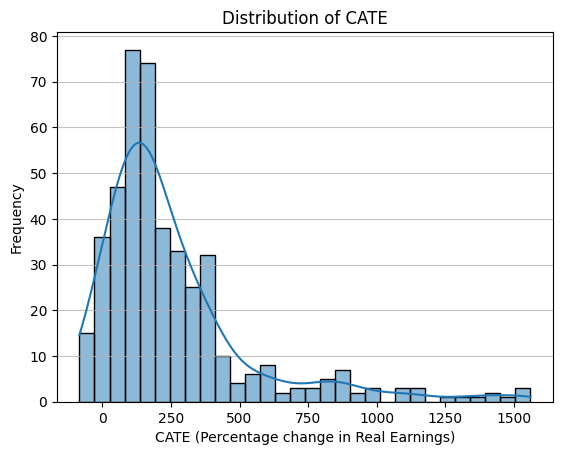

In [15]:
sns.histplot(cate_x_learner_pc_opt, bins=30, kde=True)
plt.title('Distribution of CATE')
plt.xlabel('CATE (Percentage change in Real Earnings)')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()


# Comparative Analysis

Next, I will visually compare the ATE and CATE distributions of the linear OLS regression model from before and the X-Learner.


In [16]:
# Load linear OLS again

# Initialize and train the baseline OLS model
model_base= 'lre78 ~  treat + C(black) + educ + age + lre75'

train_df, test_df = train_test_split(df, test_size=0.2, random_state=1)
y_test = test_df['lre78']

results_OLS_base = smf.ols(model_base, data=train_df).fit()


# Data preparation for AIPW

# set up model without 'treat'
model_base_aipw = 'lre78 ~ age + educ + C(black) + lre75'
tmp_aipw = smf.ols(model_base_aipw, data=df)
X_aipw = tmp_aipw.data.exog
y_aipw = tmp_aipw.data.endog
T_aipw = df['treat'].values

# Define the number of splits for cross-fitting
n_splits = 5
kf = KFold(n_splits=n_splits, shuffle=True, random_state=1)

# Initialize arrays to store out-of-fold predictions
m0_oof = np.zeros(len(df))
m1_oof = np.zeros(len(df))
p_scores_oof = np.zeros(len(df))
y_oof = np.zeros(len(df))
T_oof = np.zeros(len(df))

# Cross-fitting
for fold, (train_index, test_index) in enumerate(kf.split(X_aipw)):
    # Split data for the current fold
    X_train_fold, X_test_fold = X_aipw[train_index], X_aipw[test_index]
    y_train_fold, y_test_fold = y_aipw[train_index], y_aipw[test_index]
    T_train_fold, T_test_fold = T_aipw[train_index], T_aipw[test_index]

    # Store actual y and T values for the test fold
    y_oof[test_index] = y_test_fold
    T_oof[test_index] = T_test_fold

# Estimate propensity score (logistic regression)
    X_train_non_intercept = X_train_fold[:, 1:]
    X_test_non_intercept = X_test_fold[:, 1:]

    scaler = StandardScaler()
    X_train_scaled = np.hstack((X_train_fold[:, :1], scaler.fit_transform(X_train_non_intercept)))
    X_test_scaled = np.hstack((X_test_fold[:, :1], scaler.transform(X_test_non_intercept)))

    propensity_model = LogisticRegression(solver='liblinear', random_state=1, fit_intercept=False)
    propensity_model.fit(X_train_scaled, T_train_fold)

    # Predict propensity scores for the test fold
    p_scores_oof[test_index] = propensity_model.predict_proba(X_test_scaled)[:, 1]

# Estimate outcome model for control group (T=0)
    X_train_control = X_train_fold[T_train_fold == 0]
    y_train_control = y_train_fold[T_train_fold == 0]

    ols_m0 = sm.OLS(y_train_control, X_train_control).fit()

    m0_oof[test_index] = ols_m0.predict(X_test_fold)

# Estimate outcome model for treatment group (T=1)
    X_train_treated = X_train_fold[T_train_fold == 1]
    y_train_treated = y_train_fold[T_train_fold == 1]

    ols_m1 = sm.OLS(y_train_treated, X_train_treated).fit()

    m1_oof[test_index] = ols_m1.predict(X_test_fold)

# Ensure overlap of propensity scores (clip)
epsilon = 1e-7
p_scores_oof = np.clip(p_scores_oof, epsilon, 1 - epsilon)

# Calculate ATE with out-of-fold predictions
aipw_terms = (m1_oof - m0_oof +
              (T_oof * (y_oof - m1_oof) / p_scores_oof) +
              ((1 - T_oof) * (y_oof - m0_oof) / (1 - p_scores_oof)))

ate_aipw_crossfit = np.mean(aipw_terms)

# Calculate percentage from log values
ate_aipw_pc = (math.exp(ate_aipw_crossfit)-1)*100


# CATEs
X_covariates = df[['age', 'educ', 'black', 'lre75']].values

ols_cate = sm.OLS(aipw_terms, sm.add_constant(X_covariates)).fit() # regress on X to get conditional values

# CATEs = fitted values
cates = ols_cate.fittedvalues
cate_pc = (np.exp(cates) - 1) * 100

## Average Treatment Effects

I will start by inspecting the ATEs.

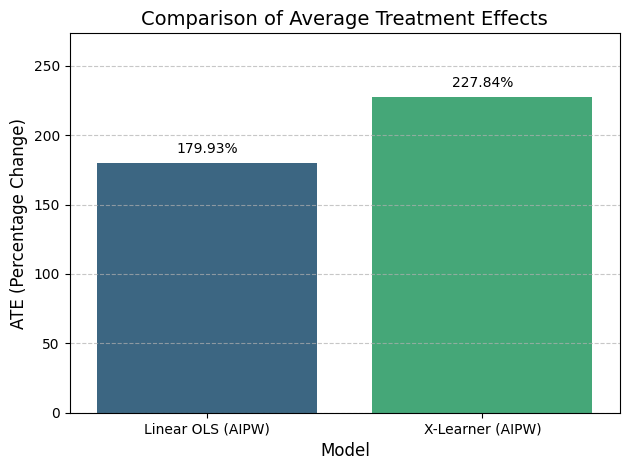

In [17]:
ate_data = {
    'Model': ['Linear OLS (AIPW)', 'X-Learner (AIPW)'],
    'ATE (%)': [ate_aipw_pc, ATE_rf_optimal_pc]
}
ate_df = pd.DataFrame(ate_data)

sns.barplot(x='Model', y='ATE (%)', data=ate_df, palette='viridis')
plt.title('Comparison of Average Treatment Effects', fontsize=14)
plt.ylabel('ATE (Percentage Change)', fontsize=12)
plt.xlabel('Model', fontsize=12)
plt.ylim(0, max(ate_df['ATE (%)']) * 1.2)
plt.grid(axis='y', linestyle='--', alpha=0.7)

for index, row in ate_df.iterrows():
    plt.text(index, row['ATE (%)'] + 5, f"{row['ATE (%)']:.2f}%", color='black', ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.show()

Both ATEs are estimated using AIPW and display positive and significant average values. The linear OLS (around 180%), however, estimates the ATE to be lower by around 50pp than the X-Learner estimate (around 230%).

As the linear model structure likely does not reflect the true underlying structural model and it might underestimate the true effect. The X-Learner does a better job here as it can identify the actual effect more appropriately.

## Conditional Average Treatment Effects

Next, I will visualize the heterogeneity of treatment effects by certain features and compare the CATEs calculated under the best regression model, the linear OLS, and the best forest model, the X-Learner.

### Aggregate

I will start by comparing the aggregate CATE plots.

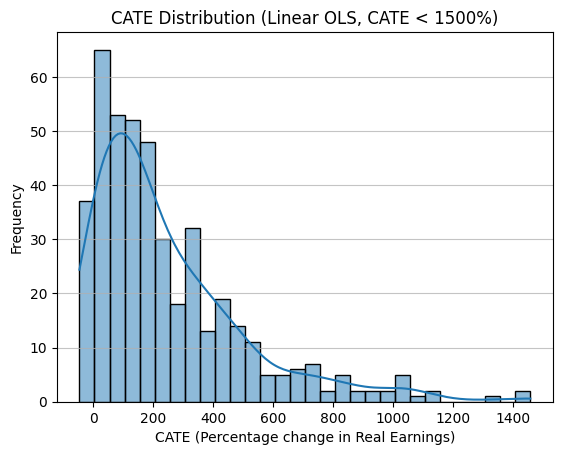

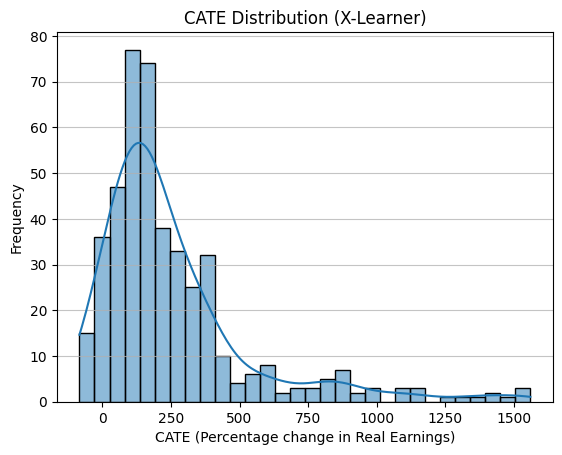

In [18]:
# Linear OLS, filtered
cate_pc_filtered = cate_pc[cate_pc < 1500]

sns.histplot(cate_pc_filtered, bins=30, kde=True)
plt.title('CATE Distribution (Linear OLS, CATE < 1500%)')
plt.xlabel('CATE (Percentage change in Real Earnings)')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

# X-Learner
sns.histplot(cate_x_learner_pc_opt, bins=30, kde=True)
plt.title('CATE Distribution (X-Learner)')
plt.xlabel('CATE (Percentage change in Real Earnings)')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()


Both CATE distributions have a similar shape overall and estimate both negative and very high positive treatment effects for some participants.

The CATE-distribution under the X-Learner, however, is more compressed than the one from the linear OLS regression, as it estimates less extreme outliers, and fewer (although absolutely higher) negative treatment effects.
For better visual comparison, I will therefore only present a filtered plot of the linear OLS CATE estimates in the following.

As the X-Learner identifies a higher ATE than the linear OLS, the peak of the CATE distribution lies at a higher CATE value than for the linear OLS regression.

### By Pre-Treatment Income

Next, I will examine the heterogeneity in effects for different subsamples. The first split I am doing is by pre-treatment income, lre75.

As the job training program was intended for people who were struggeling with employment before, it might be particularly interesting to learn about the treatment effects of those who were unemployed before the treatment, or which at least reported zero earnings in the last year before the treatment (1975).

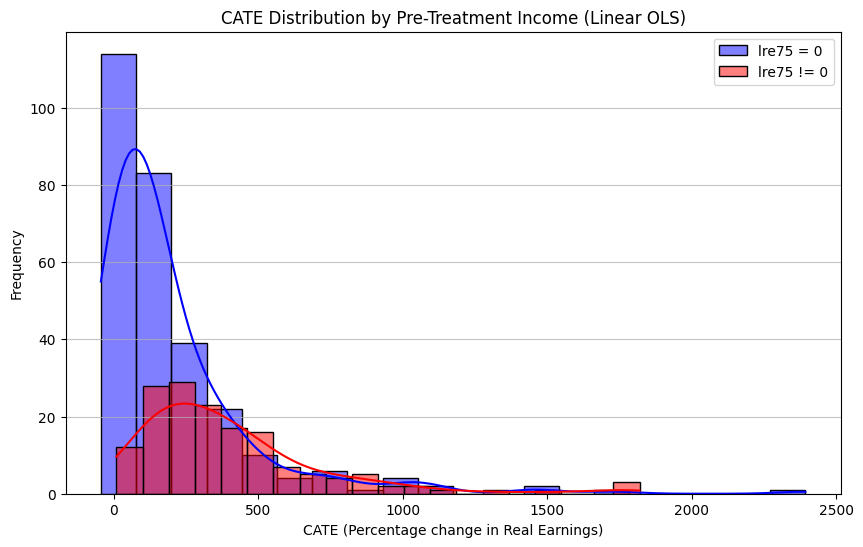

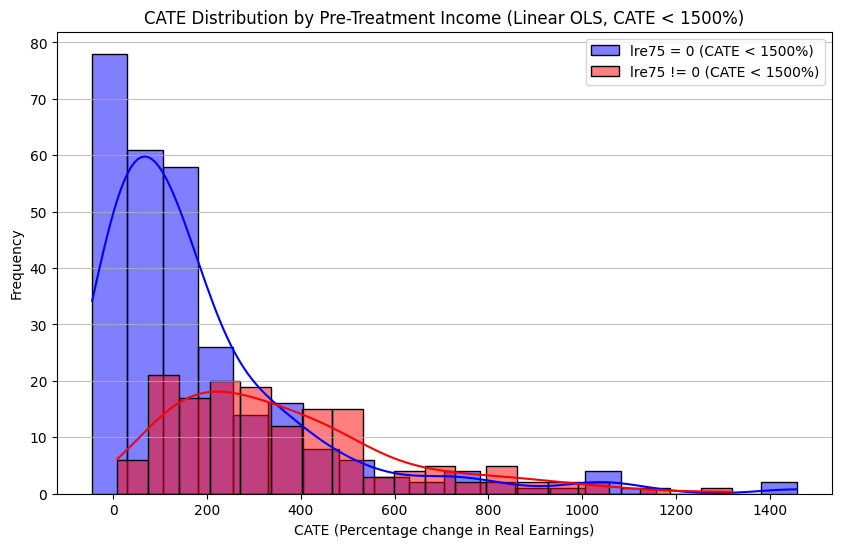

Number of participants with zero lre75 earnings: 289
Number of participants with non-zero lre75 earnings: 156


In [34]:
# Linear OLS
plot_df_lre75_comparison = pd.DataFrame({
    'CATE': cate_pc,
    'lre75': df['lre75'].values
})

# Set up 2 groups
plot_df_lre75_comparison['lre75_group'] = np.where(
    plot_df_lre75_comparison['lre75'] == 0, 'lre75 = 0', 'lre75 != 0'
)

# Mean CATE for each group
mean_cate_by_lre75_group = plot_df_lre75_comparison.groupby('lre75_group')['CATE'].mean().reset_index()

plot_df_lre75_zero = plot_df_lre75_comparison[plot_df_lre75_comparison['lre75'] == 0].copy()
plot_df_lre75_non_zero = plot_df_lre75_comparison[plot_df_lre75_comparison['lre75'] != 0].copy()

# Plot
plt.figure(figsize=(10, 6))
if not plot_df_lre75_zero.empty:
    sns.histplot(plot_df_lre75_zero['CATE'], kde=True, bins=20, color='blue', label='lre75 = 0')
    mean_cate_lre75_zero_dist = plot_df_lre75_zero['CATE'].mean()

if not plot_df_lre75_non_zero.empty:
    sns.histplot(plot_df_lre75_non_zero['CATE'], kde=True, bins=20, color='red', label='lre75 != 0')
    mean_cate_lre75_non_zero_dist = plot_df_lre75_non_zero['CATE'].mean()

plt.title('CATE Distribution by Pre-Treatment Income (Linear OLS)')
plt.xlabel('CATE (Percentage change in Real Earnings)')
plt.ylabel('Frequency')
plt.legend()
plt.grid(axis='y', alpha=0.75)
plt.show()

# Only display values <1500%
plot_df_lre75_zero_filtered = plot_df_lre75_zero[plot_df_lre75_zero['CATE'] < 1500].copy()
plot_df_lre75_non_zero_filtered = plot_df_lre75_non_zero[plot_df_lre75_non_zero['CATE'] < 1500].copy()

plt.figure(figsize=(10, 6))
if not plot_df_lre75_zero_filtered.empty:
    sns.histplot(plot_df_lre75_zero_filtered['CATE'], kde=True, bins=20, color='blue', label='lre75 = 0 (CATE < 1500%)')

if not plot_df_lre75_non_zero_filtered.empty:
    sns.histplot(plot_df_lre75_non_zero_filtered['CATE'], kde=True, bins=20, color='red', label='lre75 != 0 (CATE < 1500%)')

plt.title('CATE Distribution by Pre-Treatment Income (Linear OLS, CATE < 1500%)')
plt.xlabel('CATE (Percentage change in Real Earnings)')
plt.ylabel('Frequency')
plt.legend()
plt.grid(axis='y', alpha=0.75)
plt.show()

# Group sizes
print(f"Number of participants with zero lre75 earnings: {len(plot_df_lre75_zero)}")
print(f"Number of participants with non-zero lre75 earnings: {len(plot_df_lre75_non_zero)}")

The ranges of CATEs of the participant group with zero pre-treatment income (PTI, blue) and the non-zero PTI group (red) look relatively similar under linear OLS. The red distribution, however, does not include negative values and has its peak at around 200%. In contrast, the blue distribution also covers observations with negative treatment effects and has its peak between the minimum and around 100%.

Although the groups are quite unbalanced (290 with zero PTI vs. 155 with non-zero PTI), those with non-zero PTI are more likely to experience higher treatment effects than those with zero PTI and benefit relatively more from the participation in the job training program. For those with zero PTI, the job training program might actually harm some participants.

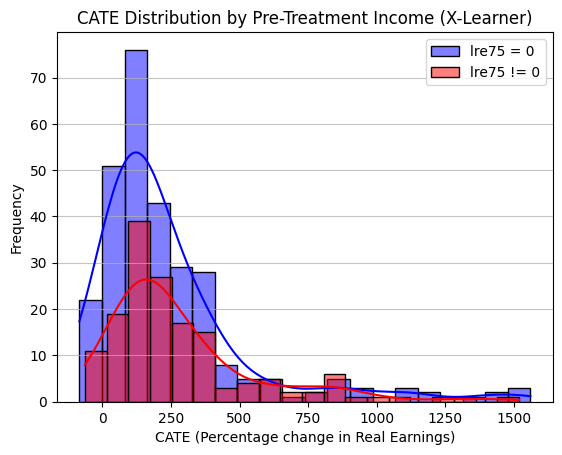

In [21]:
# X-learner
plot_df_lre75_comparison_x = pd.DataFrame({
    'CATE': cate_x_learner_pc_opt,
    'lre75': df['lre75'].values
})

# Set up 2 groups
plot_df_lre75_comparison_x['lre75_group'] = np.where(
    plot_df_lre75_comparison_x['lre75'] == 0, 'lre75 = 0', 'lre75 != 0'
)

# Mean CATE by group
mean_cate_by_lre75_group_x = plot_df_lre75_comparison_x.groupby('lre75_group')['CATE'].mean().reset_index()

plot_df_lre75_zero_x = plot_df_lre75_comparison_x[plot_df_lre75_comparison_x['lre75'] == 0].copy()
plot_df_lre75_non_zero_x = plot_df_lre75_comparison_x[plot_df_lre75_comparison_x['lre75'] != 0].copy()

# Plot
plt.figure(figsize=(10, 6))
if not plot_df_lre75_zero_x.empty:
    sns.histplot(plot_df_lre75_zero_x['CATE'], kde=True, bins=20, color='blue', label='lre75 = 0')
    mean_cate_lre75_zero_dist = plot_df_lre75_zero_x['CATE'].mean()

if not plot_df_lre75_non_zero_x.empty:
    sns.histplot(plot_df_lre75_non_zero_x['CATE'], kde=True, bins=20, color='red', label='lre75 != 0')
    mean_cate_lre75_non_zero_dist = plot_df_lre75_non_zero_x['CATE'].mean()

plt.title('CATE Distribution by Pre-Treatment Income (X-Learner)')
plt.xlabel('CATE (Percentage change in Real Earnings)')
plt.ylabel('Frequency')
plt.legend()
plt.grid(axis='y', alpha=0.75)
plt.show()

Under the X-Learner, the range and relative distribution of CATE from both PTI groups looks almost identical. For both subgroups, the X-Learner estimates negative values as well as extreme values of up to 1500%.

From the X-Learner estimates, no subgroup clearly benefits relatively more from the job training participation.

### By Race

As seen in the data characteristics, most of the disadvantaged workers that took part in the job training, were black. Therefore, I will particularly shine a light on their gains in post-treatment earnings from the job training compared to those of non-blacks.

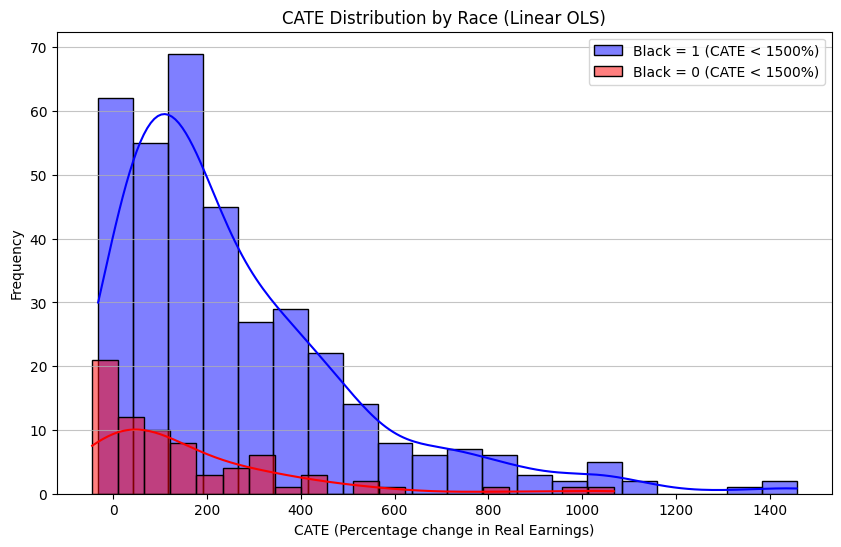

Number of black participants: 365
Number of non-black participants: 74


In [37]:
# Linear OLS
plot_df = pd.DataFrame({'CATE': cate_pc, 'Black': df['black'].values})

# Filter plot_df for Black' == 1 & ==0
plot_df_black_1 = plot_df[plot_df['Black'] == 1]
plot_df_black_0 = plot_df[plot_df['Black'] == 0]

# Filter CATE values
plot_df_black_1_filtered = plot_df_black_1[plot_df_black_1['CATE'] < 1500].copy()
plot_df_black_0_filtered = plot_df_black_0[plot_df_black_0['CATE'] < 1500].copy()

plt.figure(figsize=(10, 6))
if not plot_df_black_1_filtered.empty:
    sns.histplot(plot_df_black_1_filtered['CATE'], kde=True, bins=20, color='blue', label='Black = 1 (CATE < 1500%)')

if not plot_df_black_0_filtered.empty:
    sns.histplot(plot_df_black_0_filtered['CATE'], kde=True, bins=20, color='red', label='Black = 0 (CATE < 1500%)')

plt.title('CATE Distribution by Race (Linear OLS)')
plt.xlabel('CATE (Percentage change in Real Earnings)')
plt.ylabel('Frequency')
plt.legend()
plt.grid(axis='y', alpha=0.75)
plt.show()

# Group sizes
print(f"Number of black participants: {len(plot_df_black_1_filtered)}")
print(f"Number of non-black participants: {len(plot_df_black_0_filtered)}")

The CATE distributions from the linear OLS regression for both black participants (blue) and non-black participants (red) are skewed to the right with their peaks being between 50% and 200% for the black participants, and around zero for the non-black participants. In both groups, there are also participants that faced negative treatment effects as well as a few people that experience highly positive treatment effects.

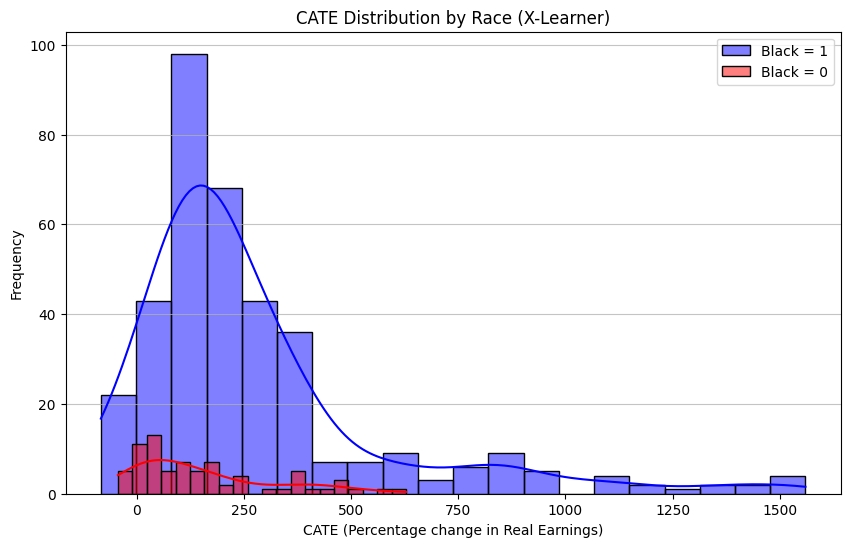

In [41]:
# X-Learner
plot_df_x = pd.DataFrame({'CATE': cate_x_learner_pc_opt, 'Black': df['black'].values})

plot_df_black_1_x = plot_df_x[plot_df_x['Black'] == 1]
plot_df_black_0_x = plot_df_x[plot_df_x['Black'] == 0]

plt.figure(figsize=(10, 6))
if not plot_df_black_1_x.empty:
    sns.histplot(plot_df_black_1_x['CATE'], kde=True, bins=20, color='blue', label='Black = 1')

if not plot_df_black_0_x.empty:
    sns.histplot(plot_df_black_0_x['CATE'], kde=True, bins=20, color='red', label='Black = 0')

plt.title('CATE Distribution by Race (X-Learner)')
plt.xlabel('CATE (Percentage change in Real Earnings)')
plt.ylabel('Frequency')
plt.legend()
plt.grid(axis='y', alpha=0.75)
plt.show()

Under the X-Learner, the distributions are not too skewed anymore, but still have a large tail to the right.
Some participants of both groups experience negative treatment effects, but the peaks of the distributions lie between 100% and 200% for the black participants and lower than 100% for the non-black participants, which is similar to the linear OLS estimations.

Taking this and the large size imbalance (365 black participants vs. 74 non-black participants) of the groups into account, black participants benefit relatively more from the job-training participation than non-black participants in this sample.

### By Years of Education


Next, I will look at the heterogeneity by years of education, as many of the disadvantaged workers might not have finished school or, let alone, received any formal training. Job training should therefore benefit all participants, but particularly also benefit those with less years of education.

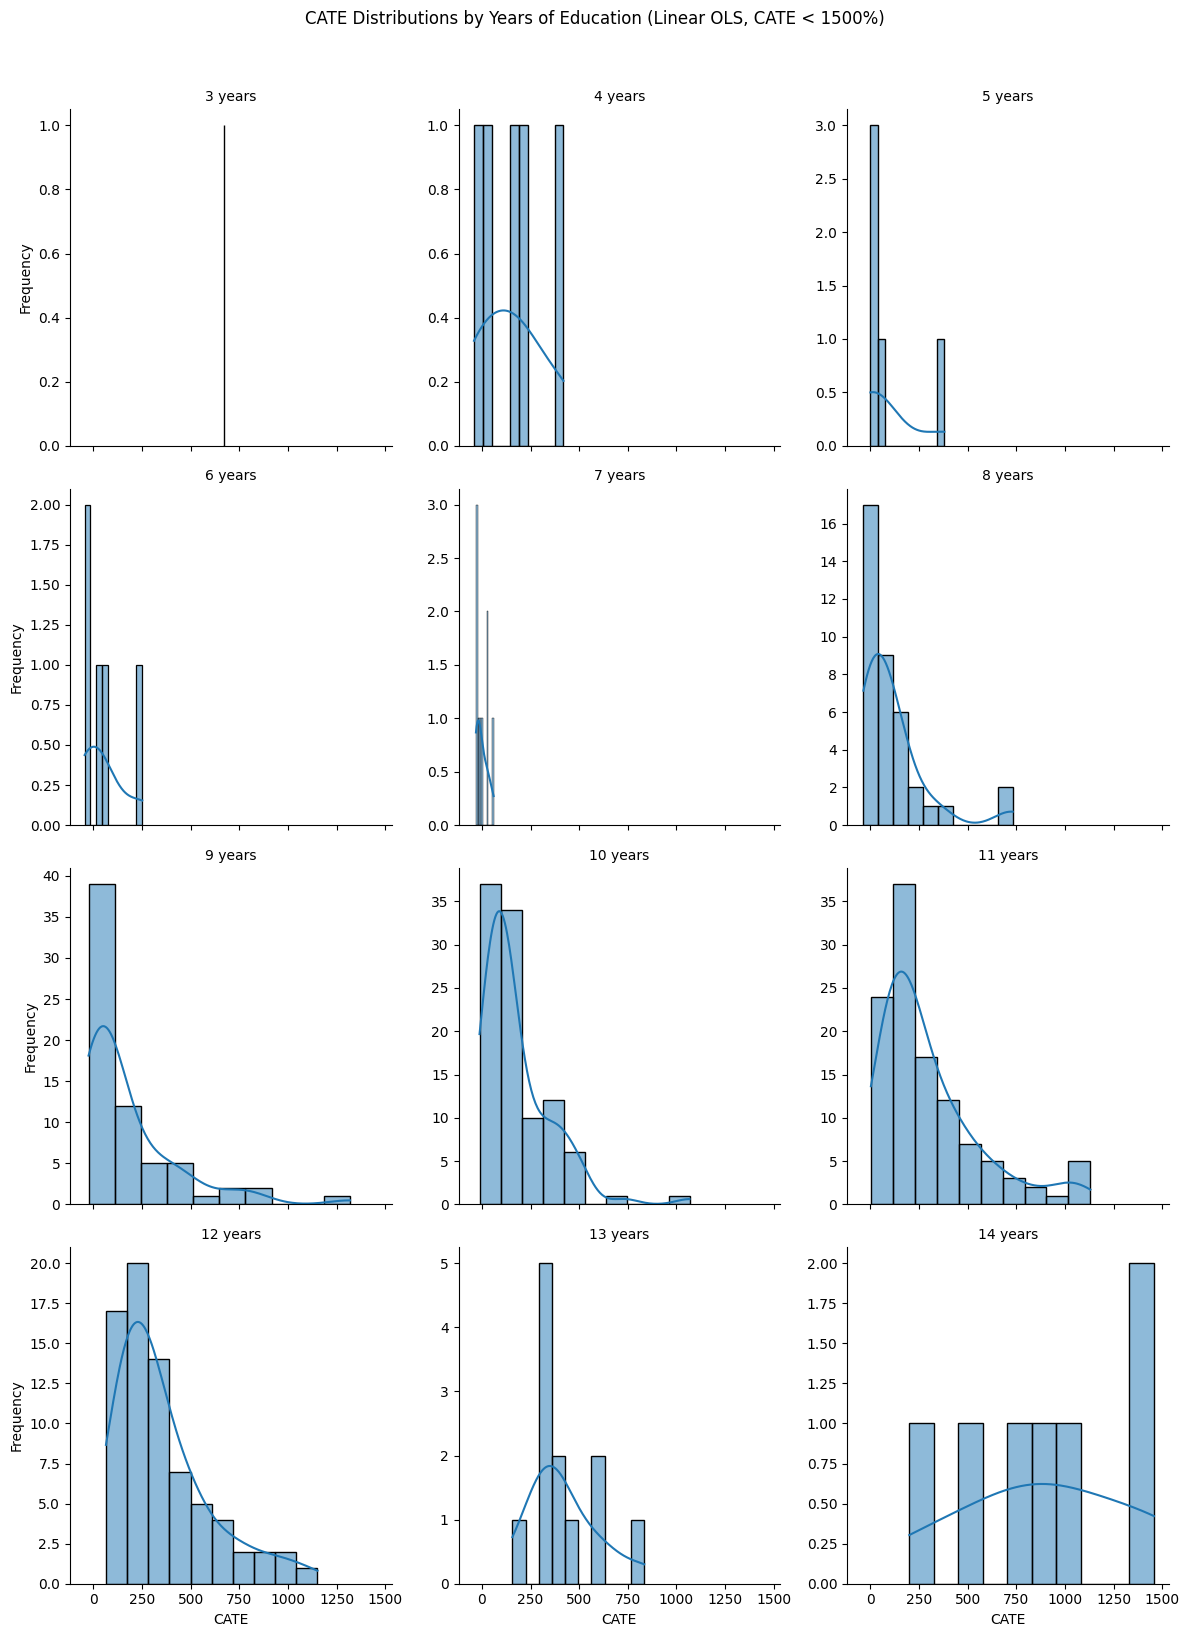

In [42]:
# Linear OLS
plot_df_educ = pd.DataFrame({'CATE': cate_pc, 'Education': df['educ'].values})
plot_df_educ_sorted = plot_df_educ.sort_values(by='Education')

# Filter CATE values
plot_df_educ_filtered = plot_df_educ_sorted[
    (plot_df_educ_sorted['CATE'] < 1500) &
    (~plot_df_educ_sorted['Education'].isin([15, 16])) # drop these plots as there are not enough observations
].copy()

graph_filtered = sns.FacetGrid(plot_df_educ_filtered, col='Education', col_wrap=3, height=4, sharex=True, sharey=False)
graph_filtered.map(sns.histplot, 'CATE', kde=True, bins=10)
graph_filtered.set_axis_labels('CATE', 'Frequency')
graph_filtered.set_titles('{col_name} years')
plt.suptitle('CATE Distributions by Years of Education (Linear OLS, CATE < 1500%)', y=1.02)
plt.tight_layout()
plt.show()

The plot shows slight evidence that participants with less than 9 years of education mainly experience quite low and sometimes also negative treatment effects. With more than 10 years of education, there are no more negative treatment effects. Also, more participants experience higher treatment effects now, which seem to increase with every year of education.

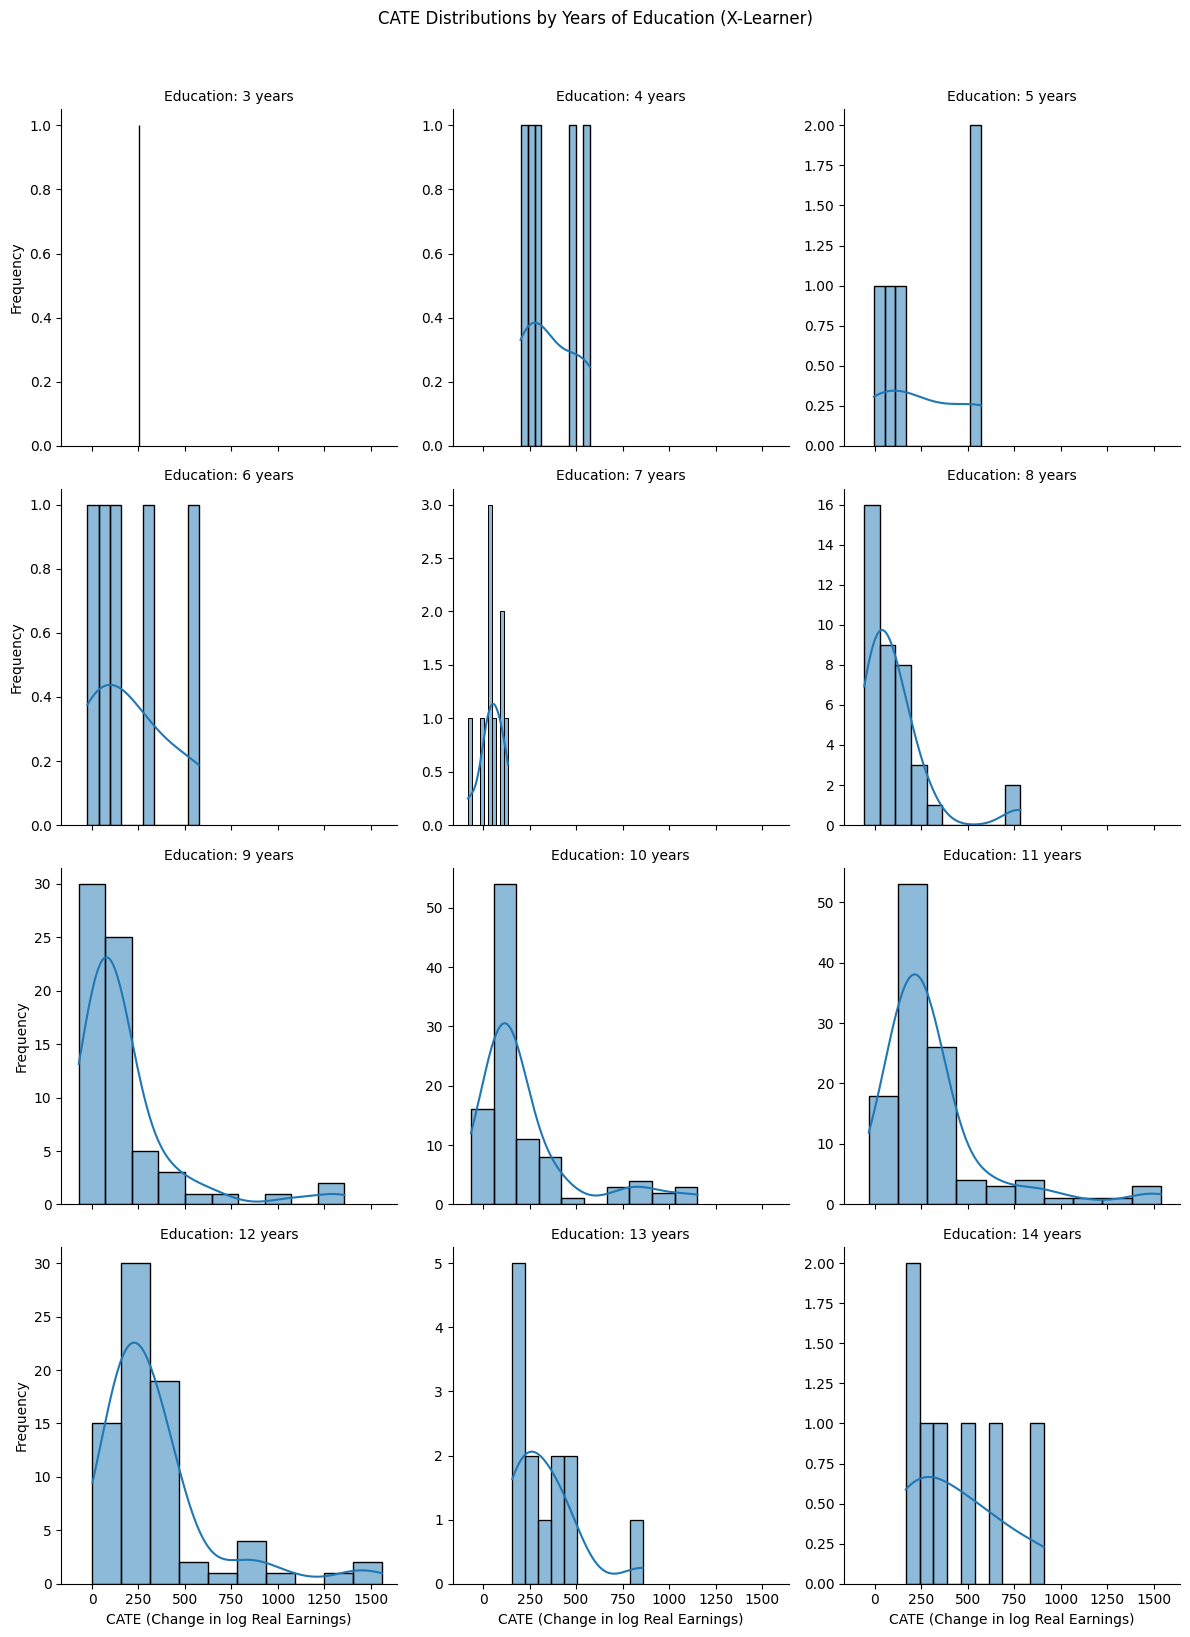

In [27]:
# X-Learner
plot_df_educ = pd.DataFrame({'CATE': cate_x_learner_pc_opt, 'Education': df['educ'].values})
plot_df_educ_sorted = plot_df_educ.sort_values(by='Education')

# Filter CATE values and specific education levels
plot_df_educ_filtered = plot_df_educ_sorted[
    (~plot_df_educ_sorted['Education'].isin([15, 16])) # drop these plots as there are not enough observations
].copy()

graph = sns.FacetGrid(plot_df_educ_filtered, col='Education', col_wrap=3, height=4, sharex=True, sharey=False)
graph.map(sns.histplot, 'CATE', kde=True, bins=10)
graph.set_axis_labels('CATE (Change in log Real Earnings)', 'Frequency')
graph.set_titles('Education: {col_name} years')
plt.suptitle('CATE Distributions by Years of Education (X-Learner)', y=1.02)
plt.tight_layout()
plt.show()

The plot of CATEs from the X-Learner show a similar picture to the one from linear OLS.

It is hard to infer meaningful results from the plots for those with less than 6 years of education due to the very small subsamples, but there is also a slight cut-off between those with less than 9 years of education and those with 10 years and more. Participants with less than 9 years mostly only experience treatment effects that are quite low and those with more than 10 years of education are more likely to experience higher treatment effects.

Taken together, participants with higher education (10 + years), e.g., those that entered high school, are more likely to benefit from higher treatment effects following the job training participation than those with less years of education, e.g., those that did not attend high school, or only the freshman year.

This "cut-off" can be seen nicely in the following plot, where I've zoomed into the years 8-11. The modus of the histogram of treatment effects increases with every additional year of education and moves away from zero after 10 years of education.

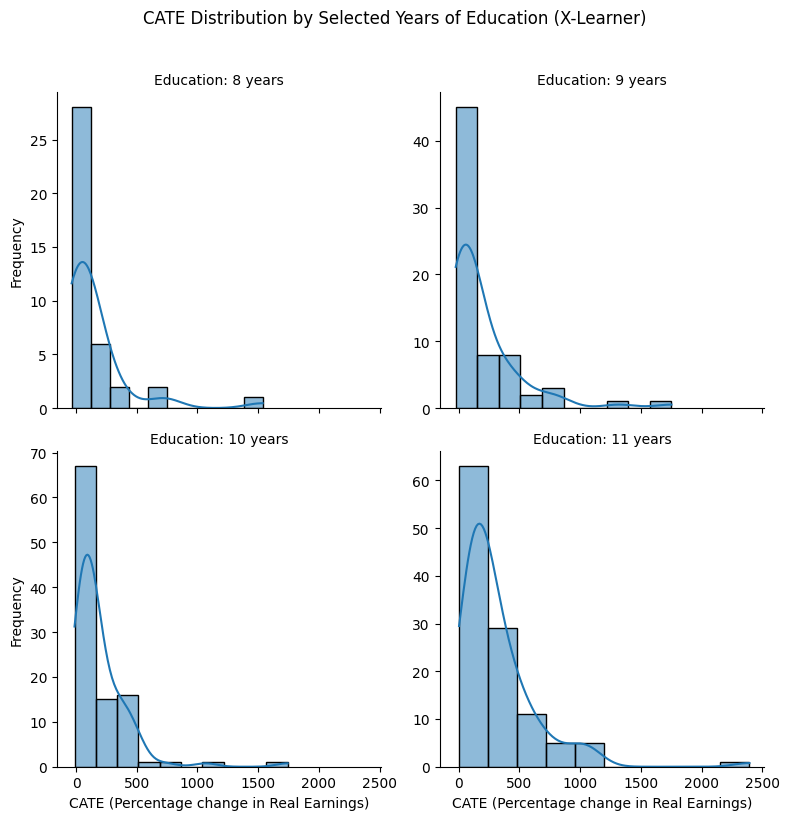

In [43]:
# 8-11 years of education
plot_df_educ_subset = pd.DataFrame({
    'CATE': cate_x_learner_pc_opt,
    'Education': df['educ'].values
})

# Filter for education years 8-11
plot_df_educ_filtered = plot_df_educ[
    plot_df_educ['Education'].isin([8, 9, 10, 11])
].copy()

graph_selected_educ = sns.FacetGrid(
    plot_df_educ_filtered,
    col='Education',
    col_wrap=2,
    height=4,
    sharex=True,
    sharey=False
)
graph_selected_educ.map(sns.histplot, 'CATE', kde=True, bins=10)
graph_selected_educ.set_axis_labels('CATE (Percentage change in Real Earnings)', 'Frequency')
graph_selected_educ.set_titles('Education: {col_name} years')
plt.suptitle('CATE Distribution by Selected Years of Education (X-Learner)', y=1.02)
plt.tight_layout()
plt.show()

### By Age

Finally, I will distinguish the treatment effects by different age groups. The mean age of all participants in the sample is around 25, so it might be interesting to find out whether younger participants benefit relatively more from job training participation than older participants, or vice versa.

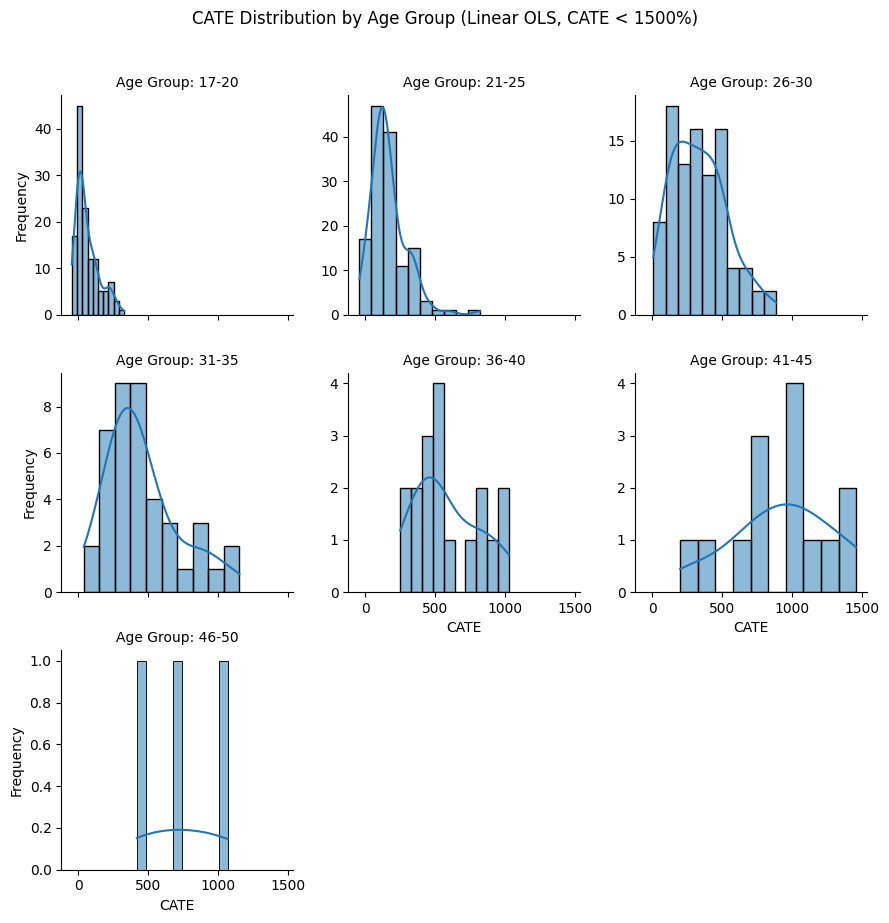

In [30]:
# Linear OLS
plot_df_age = pd.DataFrame({
    'CATE': cate_pc,
    'Age': df['age'].values
})
plot_df_age_sorted = plot_df_age.sort_values(by='Age')

# Filter CATE values
plot_df_age_filtered = plot_df_age_sorted[
    plot_df_age_sorted['CATE'] < 1500
].copy()

# Define age bins and labels for groups
age_bins = [16, 20, 25, 30, 35, 40, 45, 50]
age_labels = ['17-20', '21-25', '26-30', '31-35', '36-40', '41-45', '46-50'] # drop age groups 51-55 & 56+ as they have too few observations

plot_df_age_filtered['Age_Group'] = pd.cut(
    plot_df_age_filtered['Age'],
    bins=age_bins,
    labels=age_labels,
    right=True,
    include_lowest=True
)

graph_filtered_age = sns.FacetGrid(plot_df_age_filtered, col='Age_Group', col_wrap=3, height=3, sharex=True, sharey=False)
graph_filtered_age.map(sns.histplot, 'CATE', kde=True, bins=10)
graph_filtered_age.set_axis_labels('CATE', 'Frequency')
graph_filtered_age.set_titles('Age Group: {col_name}')
plt.suptitle('CATE Distribution by Age Group (Linear OLS, CATE < 1500%)', y=1.02)
plt.tight_layout()
plt.show()

The plot shows that, under the linear OLS regression model, most participants that are 25 years or younger experience negative treatment effects or positive effects of up to 250%, while it is more likely for the majority of older participants to experience higher treatment effects of 200-500%, and no more negative effects. The average of CATEs increases with each year group, as was the case for the effect of education.

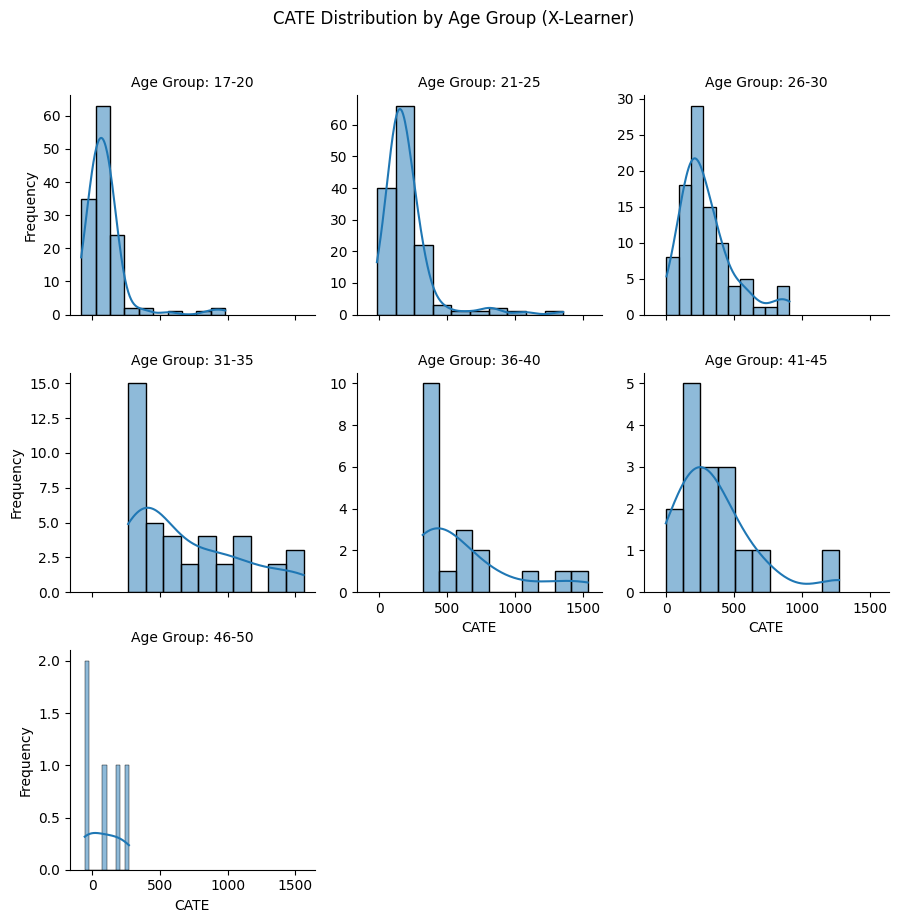

In [32]:
# X-Learner
plot_df_age = pd.DataFrame({
    'CATE': cate_x_learner_pc_opt,
    'Age': df['age'].values
})
plot_df_age_sorted = plot_df_age.sort_values(by='Age')

# Define age bins and labels for grouping
age_bins = [16, 20, 25, 30, 35, 40, 45, 50]
age_labels = ['17-20', '21-25', '26-30', '31-35', '36-40', '41-45', '46-50'] # drop age groups 51-55 & 56+

plot_df_age['Age_Group'] = pd.cut(
    plot_df_age['Age'],
    bins=age_bins,
    labels=age_labels,
    right=True,
    include_lowest=True
)

graph_age = sns.FacetGrid(plot_df_age, col='Age_Group', col_wrap=3, height=3, sharex=True, sharey=False)
graph_age.map(sns.histplot, 'CATE', kde=True, bins=10)
graph_age.set_axis_labels('CATE', 'Frequency')
graph_age.set_titles('Age Group: {col_name}')
plt.suptitle('CATE Distribution by Age Group (X-Learner)', y=1.02)
plt.tight_layout()
plt.show()

Finally, the plot of CATEs by age groups under the X-Learner also show a slight cut-off between the age groups of 21-25 and 26-30. Those younger than 25  mostly only experience treatment effects that are lower than 250% and hardly any higher effects, whereas those that are older become more likely to also experience effects higher than 250%. But again as the size of the subsample becomes smaller at the tails, results are inconclusive for the oldest age group presented here, 46-50 years.

Taken together, there is some evidence that participants older than 26 years benefit relatively more from participating in the job training than those who are younger.

# Conclusion

In this analysis of the effect of job training participation between 1975 and 1978 on male participant's post-treatment earnings in 1978, I have fitted several regression models and forest models.

The models I identified to perform the best among both classes, the linear OLS and regression forest (X-Learner), both estimated positive average treatment effects and overall quite similar conditional average treatment effects. These unveiled that a small majority of participants also experiences decreases in post-treatment earnings, while the great majority enjoys positive treatment effects and sometimes even extremely high treatment effects. These were the overall winners from job training participation.

When looking into the heterogeneity between subgroups, participants with non-zero pre-treatment earnings were found to benefit relatively more from job training participation than those with zero pre-treatment earnings. Relative to their respective other groups, black participants, those that have more than 10 years of education and those that are older than 26 were also more likely to experience higher, positive treatment effects and see increases in their post-treatment earnings.